In [1]:

!pip install mlxtend openpyxl
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
import os
print(os.listdir())

['.config', 'DATA TRANSAKSI PENJUALAN.xlsx', 'sample_data']


In [3]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import pandas as pd
from IPython.display import display, Markdown

df_raw = pd.read_excel('/content/DATA TRANSAKSI PENJUALAN.xlsx')
df_raw.head()
display(Markdown("## Tabel 1 – Data **Sebelum** Proses Data Cleaning"))
display(df_raw.head(10))

## Tabel 1 – Data **Sebelum** Proses Data Cleaning

,TANGGAL MASUK,NAMA BARANG,STOK AWAL,SATUAN/PACK,QTY/PCS,STOK MASUK,TANGGAL KELUAR,STOK KELUAR,STOK AKHIR
0,2024-09-05,Degan Sari Kelapa,1,Dus,24.0,12,2024-09-06,3.0,33.0
1,2024-09-05,Boboho Jeruk Nipis Gelas,2,Dus,48.0,1,2024-09-06,32.0,17.0
2,2024-09-05,Le Vios Gelas 240ml,2,Dus,48.0,1,2024-09-06,22.0,27.0
3,2024-09-05,Le Mineral Botol 600 ml,1,Dus,24.0,10,2024-09-06,21.0,13.0
4,2024-09-05,Le Mineral Botol 1500 ml,1,Dus,24.0,6,2024-09-06,4.0,26.0
5,2024-09-05,Kapal Api Mix 23gr,1,Dus,24.0,2,2024-09-06,20.0,6.0
6,2024-09-05,So Klin Liquid,1,Dus,24.0,10,2024-09-06,16.0,18.0
7,2024-09-05,Wipol Renceng 36ml,3,Lusin,36.0,4,2024-09-06,12.0,28.0
8,2024-09-05,Daia 1000 50gr,3,Lusin,36.0,10,2024-09-06,31.0,15.0
9,2024-09-05,Sabun Shinzui,6,Pcs,6.0,6,2024-09-06,1.0,11.0


In [4]:
# ------------------------------------------------------------
# STEP 2 — DATA CLEANING
# ------------------------------------------------------------
df_cleaned = (
    df_raw
    .drop_duplicates(subset=['NAMA BARANG', 'TANGGAL MASUK'])  # hapus duplikasi
    .dropna()  # hapus baris kosong
)

# Bersihkan nama barang
df_cleaned["NAMA BARANG"] = df_cleaned["NAMA BARANG"].astype(str).str.strip().str.lower()

# Mapping variasi nama yang sama ke satu nama
mapping_barang = {
    "aci 1/4 kg": "aci 1/4",
    "aci 1/4kg": "aci 1/4",
    "aci 1/4  kg": "aci 1/4",
    "aci 1/4": "aci 1/4",
    "terigu 1/4": "terigu 1/4",
    "terigu": "terigu",
    # tambahkan mapping lain jika ada variasi
}

df_cleaned["NAMA BARANG"] = df_cleaned["NAMA BARANG"].replace(mapping_barang)

display(Markdown("### Tabel 4.2 - Data Sesudah Proses Cek Stok Barang & Gabung Nama"))
display(df_cleaned.head(10))

### Tabel 4.2 - Data Sesudah Proses Cek Stok Barang & Gabung Nama

,TANGGAL MASUK,NAMA BARANG,STOK AWAL,SATUAN/PACK,QTY/PCS,STOK MASUK,TANGGAL KELUAR,STOK KELUAR,STOK AKHIR
0,2024-09-05,degan sari kelapa,1,Dus,24.0,12,2024-09-06,3.0,33.0
1,2024-09-05,boboho jeruk nipis gelas,2,Dus,48.0,1,2024-09-06,32.0,17.0
2,2024-09-05,le vios gelas 240ml,2,Dus,48.0,1,2024-09-06,22.0,27.0
3,2024-09-05,le mineral botol 600 ml,1,Dus,24.0,10,2024-09-06,21.0,13.0
4,2024-09-05,le mineral botol 1500 ml,1,Dus,24.0,6,2024-09-06,4.0,26.0
5,2024-09-05,kapal api mix 23gr,1,Dus,24.0,2,2024-09-06,20.0,6.0
6,2024-09-05,so klin liquid,1,Dus,24.0,10,2024-09-06,16.0,18.0
7,2024-09-05,wipol renceng 36ml,3,Lusin,36.0,4,2024-09-06,12.0,28.0
8,2024-09-05,daia 1000 50gr,3,Lusin,36.0,10,2024-09-06,31.0,15.0
9,2024-09-05,sabun shinzui,6,Pcs,6.0,6,2024-09-06,1.0,11.0


In [5]:
# ------------------------------------------------------------
# STEP 2.1 — SIMPAN KE FILE EXCEL (LOKAL /CONTENT)
# ------------------------------------------------------------
output_path = '/content/DATASET_TRANSAKSI_PENJUALAN.xlsx'

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    df_raw.to_excel(writer, sheet_name='Tabel 4.1 - Sebelum', index=False)
    df_cleaned.to_excel(writer, sheet_name='Tabel 4.2 - Sesudah', index=False)

print(f"File berhasil disimpan di: {output_path}")


File berhasil disimpan di: /content/DATASET_TRANSAKSI_PENJUALAN.xlsx


In [6]:
from google.colab import files
files.download('/content/DATASET_TRANSAKSI_PENJUALAN.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
# ------------------------------------------------------------
# STEP 3.1 — PROSES CLEANING ➜ TABEL 2
# - Hapus duplikat berdasarkan 'NAMA BARANG' dan 'TANGGAL MASUK'
# - Hapus baris kosong
# ------------------------------------------------------------
df_cleaned = (
    df_raw
      .drop_duplicates(subset=["NAMA BARANG", "TANGGAL MASUK"])
      .dropna(how="all")
      .reset_index(drop=True)
)

display(Markdown("## Tabel 2 – Data **Sesudah** Proses Data Cleaning"))
display(df_cleaned.head(10))

## Tabel 2 – Data **Sesudah** Proses Data Cleaning

,TANGGAL MASUK,NAMA BARANG,STOK AWAL,SATUAN/PACK,QTY/PCS,STOK MASUK,TANGGAL KELUAR,STOK KELUAR,STOK AKHIR
0,2024-09-05,Degan Sari Kelapa,1,Dus,24.0,12,2024-09-06,3.0,33.0
1,2024-09-05,Boboho Jeruk Nipis Gelas,2,Dus,48.0,1,2024-09-06,32.0,17.0
2,2024-09-05,Le Vios Gelas 240ml,2,Dus,48.0,1,2024-09-06,22.0,27.0
3,2024-09-05,Le Mineral Botol 600 ml,1,Dus,24.0,10,2024-09-06,21.0,13.0
4,2024-09-05,Le Mineral Botol 1500 ml,1,Dus,24.0,6,2024-09-06,4.0,26.0
5,2024-09-05,Kapal Api Mix 23gr,1,Dus,24.0,2,2024-09-06,20.0,6.0
6,2024-09-05,So Klin Liquid,1,Dus,24.0,10,2024-09-06,16.0,18.0
7,2024-09-05,Wipol Renceng 36ml,3,Lusin,36.0,4,2024-09-06,12.0,28.0
8,2024-09-05,Daia 1000 50gr,3,Lusin,36.0,10,2024-09-06,31.0,15.0
9,2024-09-05,Sabun Shinzui,6,Pcs,6.0,6,2024-09-06,1.0,11.0


In [8]:
# ------------------------------------------------------------
# STEP 3.2 — KONVERSI & INTEGRASI ➜ TABEL 3
# ------------------------------------------------------------
df = df_cleaned.copy()

# Rapikan nama kolom: hilangkan spasi ekstra, kapital semua
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True).str.strip().str.upper()

# Cek nama kolom hasil
print("== Nama kolom setelah dirapikan ==")
print(df.columns.tolist())

# Ubah kolom numerik & tanggal ke tipe yang benar
num_cols = ["STOK AWAL", "QTY/PCS", "STOK MASUK", "STOK KELUAR", "STOK AKHIR"]
date_cols = ["TANGGAL MASUK", "TANGGAL KELUAR"]

df[num_cols]  = df[num_cols].apply(pd.to_numeric, errors="coerce")
df[date_cols] = df[date_cols].apply(pd.to_datetime, errors="coerce")

# Buat kolom konversi PCS
df["STOK_AWAL_PCS"]  = df["STOK AWAL"] * df["QTY/PCS"]
df["STOK_AKHIR_PCS"] = df["STOK_AWAL_PCS"] + df["STOK MASUK"] - df["STOK KELUAR"]

# (Opsional) Cek apakah cocok dengan STOK AKHIR tercatat
df["CHECK_MATCH"] = df["STOK_AKHIR_PCS"] == df["STOK AKHIR"]

# Ambil kolom final integrasi
df_integrasi = (
    df.loc[:, ["TANGGAL MASUK", "NAMA BARANG",
               "STOK_AWAL_PCS", "STOK MASUK", "STOK KELUAR", "STOK_AKHIR_PCS"]]
      .rename(columns={
          "STOK_AWAL_PCS":  "STOK AWAL (PCS)",
          "STOK_AKHIR_PCS": "STOK AKHIR (PCS)"
      })
)

display(Markdown("## Tabel 3 – Data Stok Barang **Terintegrasi** (dalam PCS)"))
display(df_integrasi.head(10))

== Nama kolom setelah dirapikan ==
['TANGGAL MASUK', 'NAMA BARANG', 'STOK AWAL', 'SATUAN/PACK', 'QTY/PCS', 'STOK MASUK', 'TANGGAL KELUAR', 'STOK KELUAR', 'STOK AKHIR']


## Tabel 3 – Data Stok Barang **Terintegrasi** (dalam PCS)

,TANGGAL MASUK,NAMA BARANG,STOK AWAL (PCS),STOK MASUK,STOK KELUAR,STOK AKHIR (PCS)
0,2024-09-05,Degan Sari Kelapa,24.0,12,3.0,33.0
1,2024-09-05,Boboho Jeruk Nipis Gelas,96.0,1,32.0,65.0
2,2024-09-05,Le Vios Gelas 240ml,96.0,1,22.0,75.0
3,2024-09-05,Le Mineral Botol 600 ml,24.0,10,21.0,13.0
4,2024-09-05,Le Mineral Botol 1500 ml,24.0,6,4.0,26.0
5,2024-09-05,Kapal Api Mix 23gr,24.0,2,20.0,6.0
6,2024-09-05,So Klin Liquid,24.0,10,16.0,18.0
7,2024-09-05,Wipol Renceng 36ml,108.0,4,12.0,100.0
8,2024-09-05,Daia 1000 50gr,108.0,10,31.0,87.0
9,2024-09-05,Sabun Shinzui,36.0,6,1.0,41.0


In [9]:
# ---------------------------------------
# STEP 3.1.1 — PEMBENTUKAN DATA TRANSAKSI
# ---------------------------------------

df_transaksi = df_cleaned.copy()

# Apply column name cleaning to df_transaksi
df_transaksi.columns = df_transaksi.columns.str.replace(r'\s+', ' ', regex=True).str.strip().str.upper()

df_transaksi["NAMA BARANG"] = (
    df_transaksi["NAMA BARANG"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace(mapping_barang)
)
df_transaksi = df_transaksi[df_transaksi["STOK KELUAR"] > 0]
df_transaksi["TANGGAL KELUAR"] = pd.to_datetime(df_transaksi["TANGGAL KELUAR"])
transaksi = (
    df_transaksi.groupby("TANGGAL KELUAR")["NAMA BARANG"]
    .apply(lambda x: list(set(x)))  # hapus duplikat per hari
    .tolist()
)

for i, t in enumerate(transaksi[:10], start=1):
    print(f"T{i} =", t)

print("\nTotal transaksi:", len(transaksi))

T1 = ['aci 1/4', 'teh cap terompet', 'susu milo sachet', 'sosis so nice ayam', 'saos abc stick', 'sasa mecin', 'le mineral botol 600 ml', 'terasi udang', 'frisian flag putih', 'montis bantal 250lbr', 'royko ayam', 'masako ayam 500', 'gula pasir 1/4', 'so klin liquid', 'racik nasi goreng', 'wipol renceng 36ml', 'minyak sayur 1/4', 'terigu 1/4', 'energen vanila', 'telor', 'minyak sayur kemasan 1 lt', 'sabun giv', 'boboho jeruk nipis gelas', 'kapal api mix 23gr', 'tissue bantal', 'le mineral botol 1500 ml', 'sambal terasi', 'sabun shinzui', 'daia 1000 50gr', 'le vios  gelas 240ml', 'racik ayam goreng', 'racik sayur asem', 'degan sari kelapa']
T2 = ['nabati', 'santen kara', 'molto pure', 'aci 1/4', 'sprit', 'tea jus', 'fanta', 'terigu', 'susu jahe', 'pop ice mangga', 'gula pasir 1/4', 'desa ku bubuk ketumbar', 'racik nasi goreng', 'ladaku', 'kingkong', 'vioc gelas', 'desa ku kunyit', 'soklin lantai', 'telor', 'softex charm', 'teh sisri', 'yupi', 'top ice coklat', 'nutrisari peras', 'molto 

In [10]:
# ------------------------------------------------------------
# STEP 3.1.2 — ONE-HOT ENCODING
# ------------------------------------------------------------

from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(transaksi).transform(transaksi)
df_encoded = pd.DataFrame(te_array, columns=te.columns_).astype(int)

print("Data hasil One-Hot Encoding:")
display(df_encoded.head())

Data hasil One-Hot Encoding:


,abc batre remote,abc susu,aci 1/4,adem sari,adem sari chingku kaleng,ahh,ale-ale mangga,amplop paperline polos putih,aoka roti panggang,aqua botol 1500ml,...,top ice coklat,uj susu ultra coklat,uj susu ultra stroberi,ultraflu,vioc gelas,vixal botol 175ml,waffello coconut,wipol renceng 36ml,yupi,ziga biru filter 12
0,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,0,0,1,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
print("Ukuran data hasil transformasi:")
print(df_encoded.shape)


Ukuran data hasil transformasi:
(27, 246)


In [12]:
# ------------------------------------------------------------
# STEP 3.1.3 — SIMPAN & DOWNLOAD FILE
# ------------------------------------------------------------

# Simpan ke file Excel
output_file = "Data_Hasil_OneHot_Encoding_Apriori.xlsx"
df_encoded.to_excel(output_file, index=False)

# Download otomatis di Google Colab
from google.colab import files
files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
# ------------------------------------------------------------
# STEP 4 — Metode Apriori
# ------------------------------------------------------------
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(
    df_encoded,
    min_support=0.4,
    use_colnames=True
)

display(Markdown("## Frequent Itemset"))
display(frequent_itemsets)


## Frequent Itemset

,support,itemsets
0,0.481481,(masako ayam 500)
1,0.444444,(royko ayam)
2,0.481481,(telor)
3,0.444444,"(royko ayam, masako ayam 500)"


In [14]:
# ------------------------------------------------------------
# SUPPORT 1-ITEMSET
# ------------------------------------------------------------

support_1_itemset = (
    df_encoded.sum() / len(df_encoded)
).reset_index()

support_1_itemset.columns = ["Item", "Support"]

support_1_itemset


,Item,Support
0,abc batre remote,0.074074
1,abc susu,0.074074
2,aci 1/4,0.296296
3,adem sari,0.074074
4,adem sari chingku kaleng,0.111111
...,...,...
241,vixal botol 175ml,0.037037
242,waffello coconut,0.074074
243,wipol renceng 36ml,0.296296
244,yupi,0.296296


In [21]:
support_1_itemset = (
    df_encoded.sum() / len(df_encoded)
).reset_index()

support_1_itemset.columns = ["Item", "Support"]

# Filter minimal 20%
support_1_itemset = support_1_itemset[support_1_itemset["Support"] >= 0.2]

support_1_itemset

,Item,Support
2,aci 1/4,0.296296
29,citrun,0.222222
34,desa ku kunyit,0.259259
39,djarum coklat 12,0.296296
42,djarum super 12,0.259259
50,garam refina,0.259259
58,gudang garam merah 12,0.259259
59,gula pasir 1/4,0.296296
67,indomie goreng,0.259259
78,kapal api mix 23gr,0.259259


In [22]:
print("Support:", len(support_1_itemset))
support_1_itemset.head(5)

Support: 30


,Item,Support
2,aci 1/4,0.296296
29,citrun,0.222222
34,desa ku kunyit,0.259259
39,djarum coklat 12,0.296296
42,djarum super 12,0.259259


In [23]:
# ------------------------------------------------------------
# SUPPORT 2-ITEMSET
# ------------------------------------------------------------

from itertools import combinations

total_transaksi = len(df_encoded)
hasil_support_2 = []

for item_a, item_b in combinations(df_encoded.columns, 2):
    jumlah = ((df_encoded[item_a] == 1) & (df_encoded[item_b] == 1)).sum()
    support = jumlah / total_transaksi

    hasil_support_2.append({
        "Itemset": f"{item_a}, {item_b}",
        "Support": support
    })

support_2_itemset = pd.DataFrame(hasil_support_2)
support_2_itemset


,Itemset,Support
0,"abc batre remote, abc susu",0.000000
1,"abc batre remote, aci 1/4",0.037037
2,"abc batre remote, adem sari",0.000000
3,"abc batre remote, adem sari chingku kaleng",0.074074
4,"abc batre remote, ahh",0.000000
...,...,...
30130,"waffello coconut, yupi",0.000000
30131,"waffello coconut, ziga biru filter 12",0.000000
30132,"wipol renceng 36ml, yupi",0.111111
30133,"wipol renceng 36ml, ziga biru filter 12",0.037037


In [24]:
# ------------------------------------------------------------
# SUPPORT 2-ITEMSET
# ------------------------------------------------------------

from itertools import combinations
import pandas as pd

total_transaksi = len(df_encoded)
hasil_support_2 = []

for item_a, item_b in combinations(df_encoded.columns, 2):
    jumlah = ((df_encoded[item_a] == 1) & (df_encoded[item_b] == 1)).sum()
    support = jumlah / total_transaksi

    hasil_support_2.append({
        "Itemset": f"{item_a}, {item_b}",
        "Support": support
    })

support_2_itemset = pd.DataFrame(hasil_support_2)

# 🔥 Filter minimal 20%
support_2_itemset = support_2_itemset[support_2_itemset["Support"] >= 0.2]

support_2_itemset

,Itemset,Support
536,"aci 1/4, garam refina",0.222222
545,"aci 1/4, gula pasir 1/4",0.259259
578,"aci 1/4, ladaku",0.222222
605,"aci 1/4, masako ayam 500",0.259259
612,"aci 1/4, minyak sayur 1/4",0.222222
...,...,...
28834,"sasa mecin, teh cap terompet",0.259259
28841,"sasa mecin, telor",0.222222
29816,"teh cap terompet, telor",0.222222
29857,"teh gelas kemasan gelas, yupi",0.259259


In [25]:
print("Support:", len(support_2_itemset))
support_2_itemset.head(5)

Support: 67


,Itemset,Support
536,"aci 1/4, garam refina",0.222222
545,"aci 1/4, gula pasir 1/4",0.259259
578,"aci 1/4, ladaku",0.222222
605,"aci 1/4, masako ayam 500",0.259259
612,"aci 1/4, minyak sayur 1/4",0.222222


In [60]:
# ------------------------------------------------------------
# CONFIDENCE A → B
# ------------------------------------------------------------

hasil_confidence = []

for item_a, item_b in combinations(df_encoded.columns, 2):
    support_ab = ((df_encoded[item_a] == 1) & (df_encoded[item_b] == 1)).sum()
    support_a = (df_encoded[item_a] == 1).sum()
    support_b = (df_encoded[item_b] == 1).sum()

    if support_a > 0:
        conf_ab = support_ab / support_a
        hasil_confidence.append({
            "Rule": f"{item_a} → {item_b}",
            "Confidence": conf_ab
        })

    if support_b > 0:
        conf_ba = support_ab / support_b
        hasil_confidence.append({
            "Rule": f"{item_b} → {item_a}",
            "Confidence": conf_ba
        })

df_confidence = pd.DataFrame(hasil_confidence)
df_confidence

# 🔥 Filter minimal 40%
df_confidence = df_confidence[df_confidence["Confidence"] >= 0.4]

df_confidence


,Rule,Confidence
2,abc batre remote → aci 1/4,0.500000
6,abc batre remote → adem sari chingku kaleng,1.000000
7,adem sari chingku kaleng → abc batre remote,0.666667
14,abc batre remote → aoka roti panggang,0.500000
16,abc batre remote → aqua botol 1500ml,0.500000
...,...,...
60233,waffello coconut → ultraflu,0.500000
60242,vioc gelas → waffello coconut,0.500000
60243,waffello coconut → vioc gelas,0.500000
60246,vioc gelas → yupi,0.500000


In [61]:
print("Confidence:", len(df_confidence))
df_confidence.head(5)

Confidence: 7953


,Rule,Confidence
2,abc batre remote → aci 1/4,0.500000
6,abc batre remote → adem sari chingku kaleng,1.000000
7,adem sari chingku kaleng → abc batre remote,0.666667
14,abc batre remote → aoka roti panggang,0.500000
16,abc batre remote → aqua botol 1500ml,0.500000


In [27]:
# ------------------------------------------------------------
# ASSOCIATION RULE
# ------------------------------------------------------------

association_rules_list = []

for item_a, item_b in combinations(df_encoded.columns, 2):
    support_ab = ((df_encoded[item_a] == 1) & (df_encoded[item_b] == 1)).sum()
    support_a = (df_encoded[item_a] == 1).sum()
    support_b = (df_encoded[item_b] == 1).sum()

    if support_a > 0 and support_b > 0:
        supp_ab = support_ab / total_transaksi
        conf_ab = support_ab / support_a
        conf_ba = support_ab / support_b
        lift_ab = conf_ab / (support_b / total_transaksi)
        lift_ba = conf_ba / (support_a / total_transaksi)

        association_rules_list.extend([
            {
                "Antecedent": item_a,
                "Consequent": item_b,
                "Support": supp_ab,
                "Confidence": conf_ab,
                "Lift": lift_ab
            },
            {
                "Antecedent": item_b,
                "Consequent": item_a,
                "Support": supp_ab,
                "Confidence": conf_ba,
                "Lift": lift_ba
            }
        ])

df_rules = pd.DataFrame(association_rules_list)
df_rules


,Antecedent,Consequent,Support,Confidence,Lift
0,abc batre remote,abc susu,0.000000,0.000000,0.000000
1,abc susu,abc batre remote,0.000000,0.000000,0.000000
2,abc batre remote,aci 1/4,0.037037,0.500000,1.687500
3,aci 1/4,abc batre remote,0.037037,0.125000,1.687500
4,abc batre remote,adem sari,0.000000,0.000000,0.000000
...,...,...,...,...,...
60265,yupi,wipol renceng 36ml,0.111111,0.375000,1.265625
60266,wipol renceng 36ml,ziga biru filter 12,0.037037,0.125000,0.562500
60267,ziga biru filter 12,wipol renceng 36ml,0.037037,0.166667,0.562500
60268,yupi,ziga biru filter 12,0.074074,0.250000,1.125000


In [28]:
df_rules_filtered = df_rules[
    (df_rules["Support"] >= 0.2) &
    (df_rules["Confidence"] >= 0.10) &
    (df_rules["Lift"] > 1)
]

df_rules_filtered


,Antecedent,Consequent,Support,Confidence,Lift
1072,aci 1/4,garam refina,0.222222,0.750000,2.892857
1073,garam refina,aci 1/4,0.222222,0.857143,2.892857
1090,aci 1/4,gula pasir 1/4,0.259259,0.875000,2.953125
1091,gula pasir 1/4,aci 1/4,0.259259,0.875000,2.953125
1156,aci 1/4,ladaku,0.222222,0.750000,2.892857
...,...,...,...,...,...
59633,telor,teh cap terompet,0.222222,0.461538,1.780220
59714,teh gelas kemasan gelas,yupi,0.259259,0.777778,2.625000
59715,yupi,teh gelas kemasan gelas,0.259259,0.875000,2.625000
59992,terasi udang,wipol renceng 36ml,0.259259,1.000000,3.375000


In [29]:
print("Jumlah rule:", len(df_rules_filtered))
df_rules_filtered.head(10)

Jumlah rule: 134


,Antecedent,Consequent,Support,Confidence,Lift
1072,aci 1/4,garam refina,0.222222,0.750000,2.892857
1073,garam refina,aci 1/4,0.222222,0.857143,2.892857
1090,aci 1/4,gula pasir 1/4,0.259259,0.875000,2.953125
1091,gula pasir 1/4,aci 1/4,0.259259,0.875000,2.953125
1156,aci 1/4,ladaku,0.222222,0.750000,2.892857
1157,ladaku,aci 1/4,0.222222,0.857143,2.892857
1210,aci 1/4,masako ayam 500,0.259259,0.875000,1.817308
1211,masako ayam 500,aci 1/4,0.259259,0.538462,1.817308
1224,aci 1/4,minyak sayur 1/4,0.222222,0.750000,3.375000
1225,minyak sayur 1/4,aci 1/4,0.222222,1.000000,3.375000


In [30]:
# Filter rules sesuai kriteria
df_rules_filtered = df_rules[
    (df_rules["Support"] >= 0.2) &
    (df_rules["Confidence"] >= 0.10) &
    (df_rules["Lift"] > 1)
]

df_rules_filtered.head()

,Antecedent,Consequent,Support,Confidence,Lift
1072,aci 1/4,garam refina,0.222222,0.750000,2.892857
1073,garam refina,aci 1/4,0.222222,0.857143,2.892857
1090,aci 1/4,gula pasir 1/4,0.259259,0.875000,2.953125
1091,gula pasir 1/4,aci 1/4,0.259259,0.875000,2.953125
1156,aci 1/4,ladaku,0.222222,0.750000,2.892857


In [31]:
df_graph = df_rules[
    (df_rules["Support"] >= 0.2) &
    (df_rules["Confidence"] >= 0.10) &
    (df_rules["Lift"] > 1)
]

In [32]:
import networkx as nx
G = nx.DiGraph()  # Directed graph (arah)

for _, row in df_graph.iterrows():
    antecedent = row["Antecedent"]
    consequent = row["Consequent"]
    weight = row["Lift"]

    G.add_edge(antecedent, consequent, weight=weight)

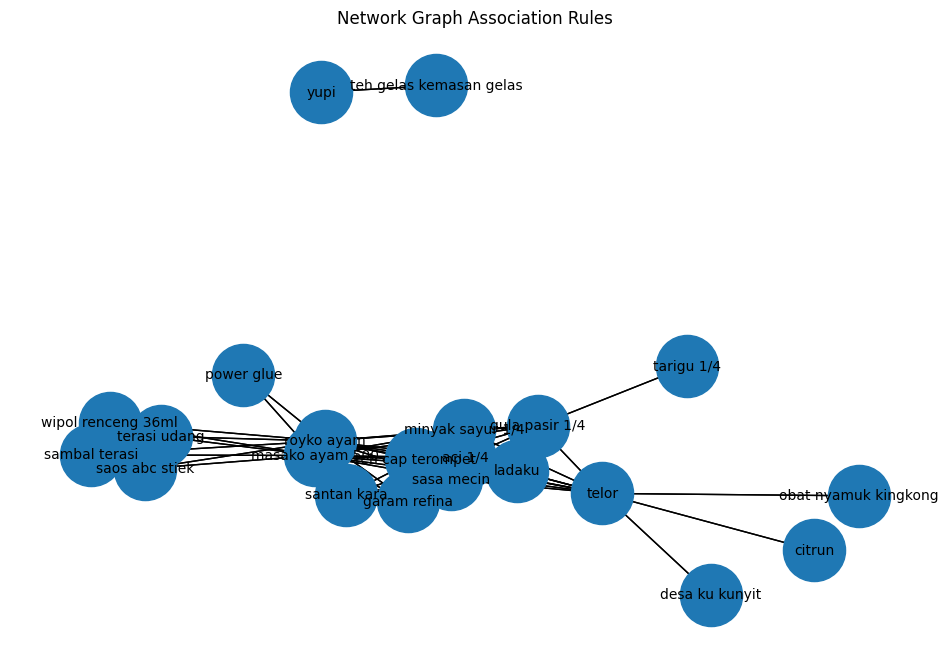

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

pos = nx.spring_layout(G, k=0.5)

# Gambar node
nx.draw_networkx_nodes(G, pos, node_size=2000)

# Gambar edge
nx.draw_networkx_edges(G, pos, arrows=True)

# Label node
nx.draw_networkx_labels(G, pos, font_size=10)

plt.title("Network Graph Association Rules")
plt.axis('off')
plt.show()

In [34]:
top_rules = df_graph.sort_values(by="Lift", ascending=False).head(10)

G = nx.DiGraph()

for _, row in top_rules.iterrows():
    G.add_edge(row["Antecedent"], row["Consequent"], weight=row["Lift"])

Jumlah rules: 10


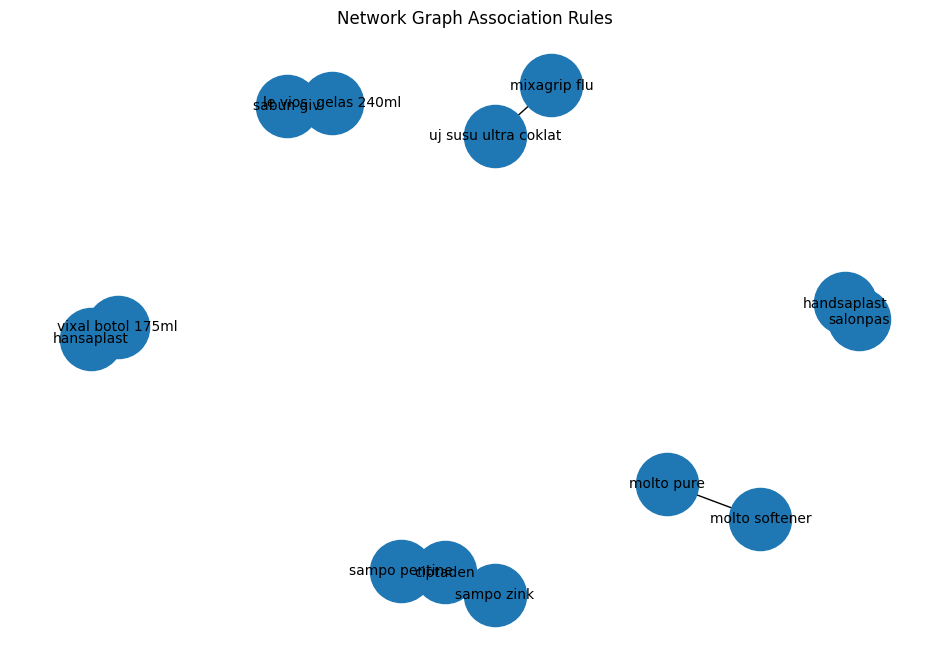

In [35]:
import networkx as nx
import matplotlib.pyplot as plt

# Filter rules
df_graph = df_rules[
    (df_rules["Confidence"] >= 0.4) &
    (df_rules["Lift"] > 1)
]

# Ambil Top 10
top_rules = df_graph.sort_values(by="Lift", ascending=False).head(10)

print("Jumlah rules:", len(top_rules))

# Buat graph
G = nx.DiGraph()

for _, row in top_rules.iterrows():
    G.add_edge(str(row["Antecedent"]), str(row["Consequent"]), weight=row["Lift"])

# Visualisasi
plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, k=0.5)

nx.draw_networkx_nodes(G, pos, node_size=2000)
nx.draw_networkx_edges(G, pos, arrows=True)
nx.draw_networkx_labels(G, pos, font_size=10)

plt.title("Network Graph Association Rules")
plt.axis('off')
plt.show()

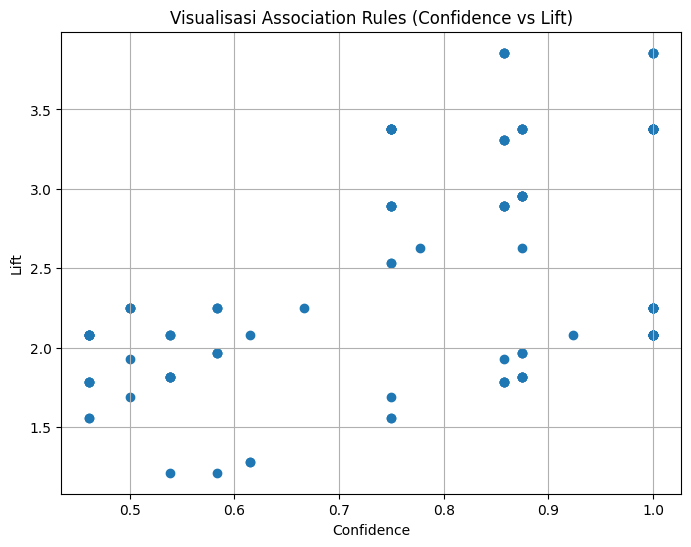

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df_rules_filtered["Confidence"],
    df_rules_filtered["Lift"]
)

plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.title("Visualisasi Association Rules (Confidence vs Lift)")

plt.grid(True)
plt.show()

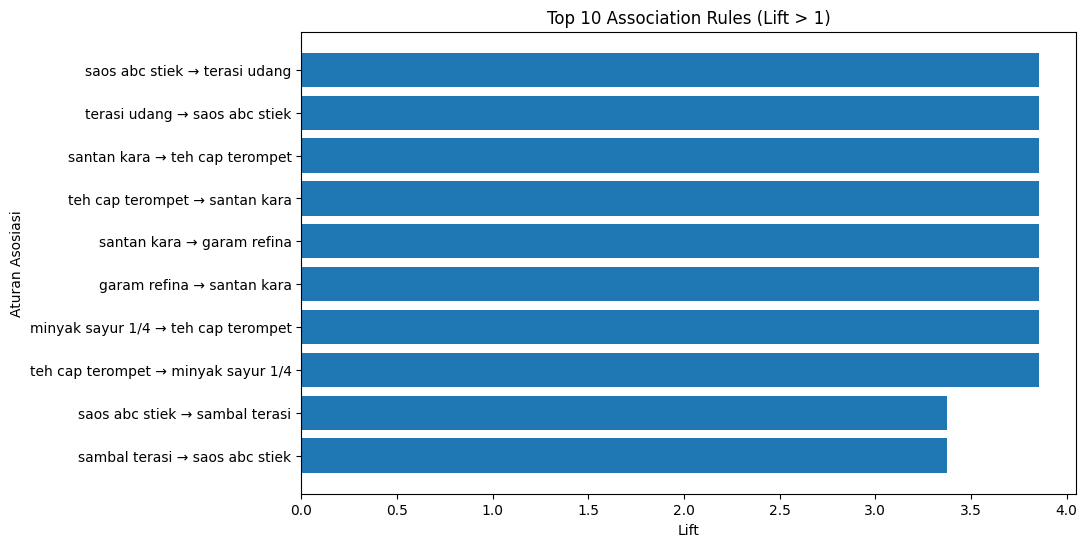

In [37]:
# Ambil Top 10 berdasarkan lift
top_rules = df_rules_filtered.sort_values(by="Lift", ascending=False).head(10)

# Gabungkan nama rule
top_rules["Rule"] = top_rules["Antecedent"] + " → " + top_rules["Consequent"]

plt.figure(figsize=(10,6))

plt.barh(top_rules["Rule"], top_rules["Lift"])

plt.xlabel("Lift")
plt.ylabel("Aturan Asosiasi")
plt.title("Top 10 Association Rules (Lift > 1)")

plt.gca().invert_yaxis()
plt.show()

In [38]:
# Hitung jumlah transaksi tiap produk
produk_terlaris = df_encoded.sum().sort_values(ascending=False)

# Ubah ke DataFrame
df_produk_terlaris = produk_terlaris.reset_index()
df_produk_terlaris.columns = ["Produk", "Jumlah_Transaksi"]

# Ambil Top 10 produk
top10_produk = df_produk_terlaris.head(10)

top10_produk

,Produk,Jumlah_Transaksi
0,telor,13
1,masako ayam 500,13
2,royko ayam,12
3,teh gelas kemasan gelas,9
4,aci 1/4,8
5,djarum coklat 12,8
6,wipol renceng 36ml,8
7,yupi,8
8,sambal terasi,8
9,sasa mecin,8


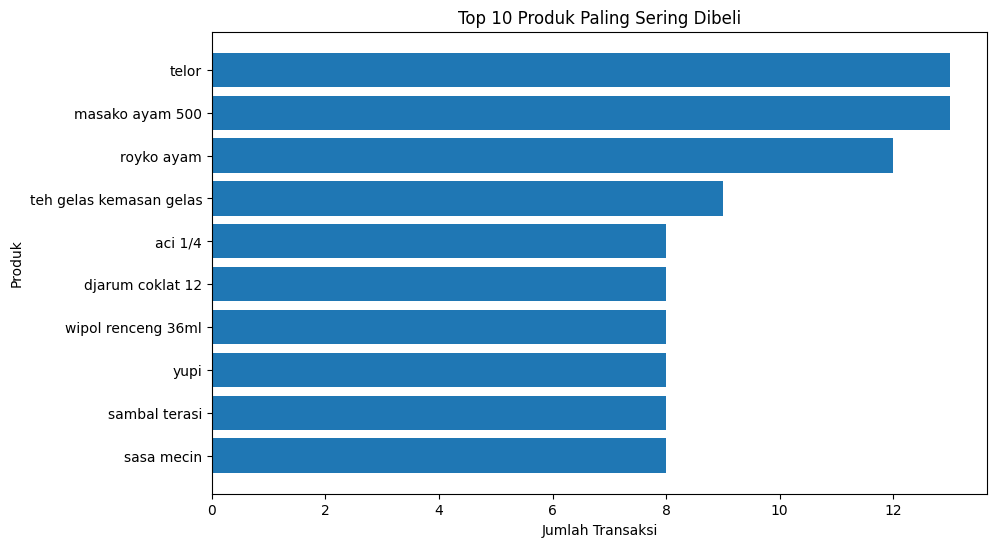

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(top10_produk["Produk"], top10_produk["Jumlah_Transaksi"])

plt.xlabel("Jumlah Transaksi")
plt.ylabel("Produk")
plt.title("Top 10 Produk Paling Sering Dibeli")

plt.gca().invert_yaxis()  # agar yang tertinggi di atas
plt.show()

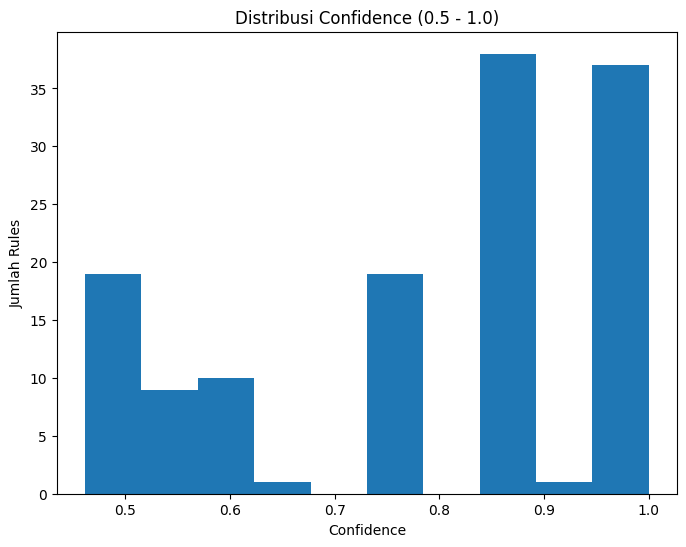

In [40]:
plt.figure(figsize=(8,6))

plt.hist(df_rules_filtered["Confidence"], bins=10)

plt.xlabel("Confidence")
plt.ylabel("Jumlah Rules")
plt.title("Distribusi Confidence (0.5 - 1.0)")

plt.show()

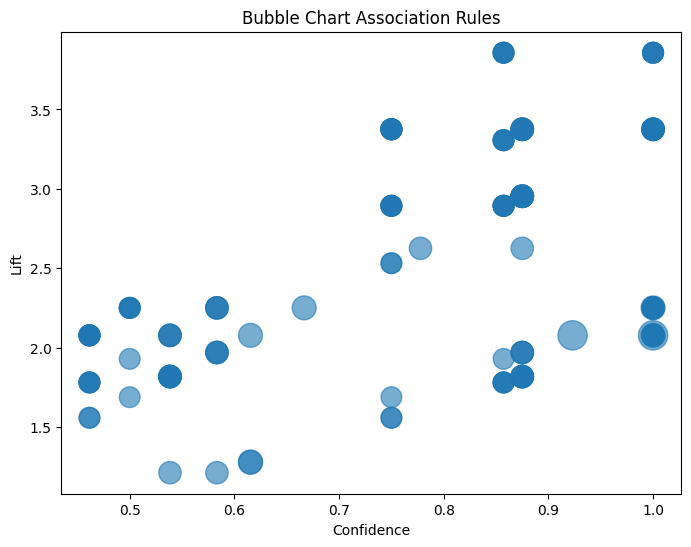

In [41]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_rules_filtered["Confidence"],
    df_rules_filtered["Lift"],
    s=df_rules_filtered["Support"]*1000,  # ukuran berdasarkan support
    alpha=0.6
)

plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.title("Bubble Chart Association Rules")

plt.show()

In [42]:
total_transaksi = len(df_encoded)
print("Total transaksi:", total_transaksi)

Total transaksi: 27


In [43]:
support_aci = df_encoded["masako ayam 500"].sum() / total_transaksi
print("Support masako ayam 500:", support_aci)

Support masako ayam 500: 0.48148148148148145


In [44]:
jumlah_ziga = (df_encoded["royko ayam"] == 1).sum()
print("Jumlah transaksi royko ayam 12:", jumlah_ziga)

Jumlah transaksi royko ayam 12: 12


In [45]:
# jumlah transaksi kedua barang
jumlah_keduanya = (
    (df_encoded["royko ayam"] == 1) &
    (df_encoded["masako ayam 500"] == 1)
).sum()

print("Jumlah transaksi kedua barang:", jumlah_keduanya)

# support kedua barang
support_keduanya = jumlah_keduanya / total_transaksi
print("Support kedua barang:", support_keduanya)

Jumlah transaksi kedua barang: 12
Support kedua barang: 0.4444444444444444


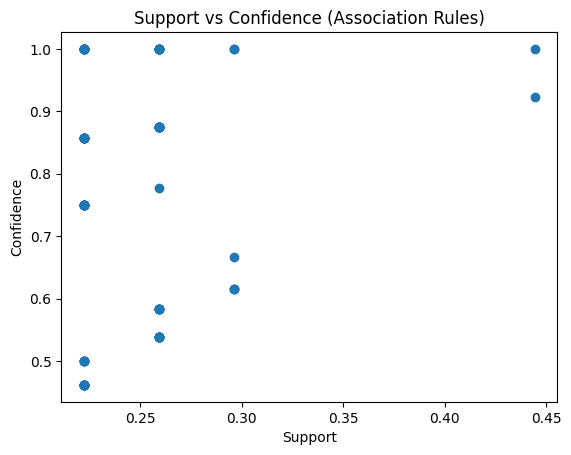

In [46]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1️⃣ Scatter Plot: Support vs Confidence
# ------------------------------------------------------------
plt.figure()
plt.scatter(
    df_rules_filtered["Support"],
    df_rules_filtered["Confidence"]
)
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence (Association Rules)")
plt.show()


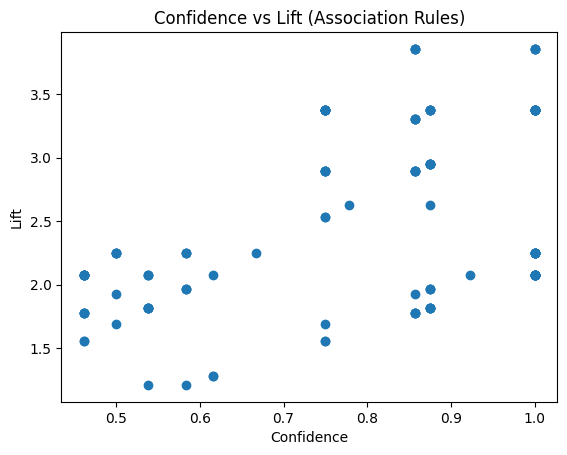

In [47]:
# ------------------------------------------------------------
# 2️⃣ Scatter Plot: Confidence vs Lift
# ------------------------------------------------------------
plt.figure()
plt.scatter(
    df_rules_filtered["Confidence"],
    df_rules_filtered["Lift"]
)
plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.title("Confidence vs Lift (Association Rules)")
plt.show()


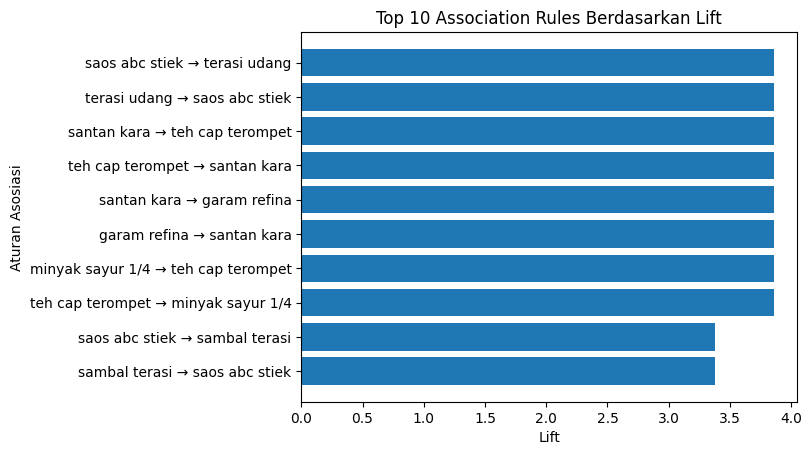

In [48]:
# ------------------------------------------------------------
# 3️⃣ Bar Chart: Top 10 Rule Berdasarkan Lift
# ------------------------------------------------------------
top_lift = df_rules_filtered.sort_values("Lift", ascending=False).head(10)

plt.figure()
plt.barh(
    top_lift["Antecedent"] + " → " + top_lift["Consequent"],
    top_lift["Lift"]
)
plt.xlabel("Lift")
plt.ylabel("Aturan Asosiasi")
plt.title("Top 10 Association Rules Berdasarkan Lift")
plt.gca().invert_yaxis()
plt.show()


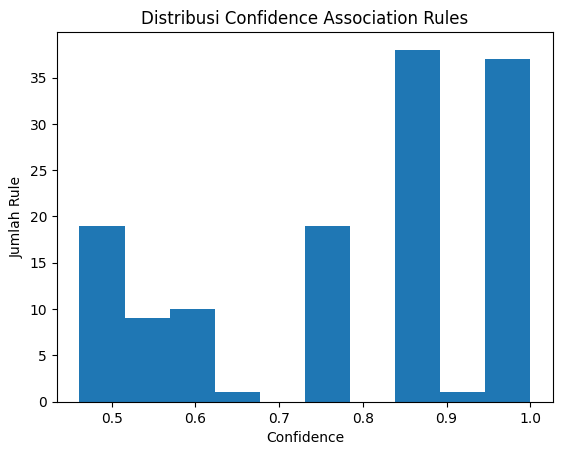

In [49]:
# ------------------------------------------------------------
# 4️⃣ Histogram: Distribusi Confidence
# ------------------------------------------------------------
plt.figure()
plt.hist(df_rules_filtered["Confidence"], bins=10)
plt.xlabel("Confidence")
plt.ylabel("Jumlah Rule")
plt.title("Distribusi Confidence Association Rules")
plt.show()

<Figure size 640x480 with 0 Axes>

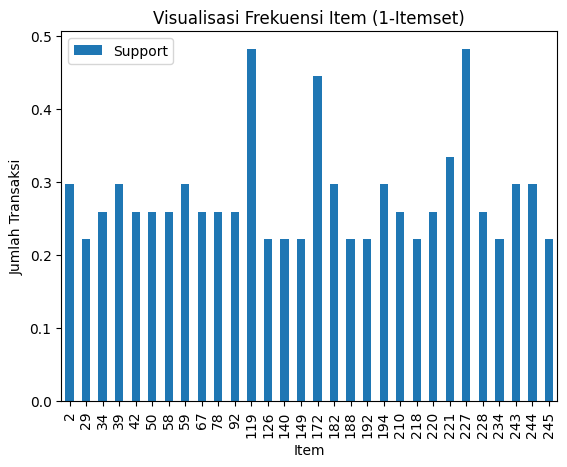

In [50]:
# ===============================
# VISUALISASI BAR CHART
# ===============================
plt.figure()
support_1_itemset.plot(kind='bar')
plt.xlabel('Item')
plt.ylabel('Jumlah Transaksi')
plt.title('Visualisasi Frekuensi Item (1-Itemset)')
plt.show()

In [51]:
total_transaksi = len(df_encoded)

min_transaksi = 20  # minimal muncul di 20 transaksi
minsup = min_transaksi / total_transaksi

print("Minimum Support:", minsup)

Minimum Support: 0.7407407407407407


In [ ]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.5
)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(royko ayam),(masako ayam 500),0.444444,0.481481,0.444444,1.000000,2.076923,1.0,0.230453,inf,0.933333,0.923077,1.000000,0.961538
1,(masako ayam 500),(royko ayam),0.481481,0.444444,0.444444,0.923077,2.076923,1.0,0.230453,7.222222,1.000000,0.923077,0.861538,0.961538


In [53]:
# Filter rules sesuai kriteria
df_rules_filtered = df_rules[
    (df_rules["Support"] > 0.2) &
    (df_rules["Lift"] > 1)
]

# Tampilkan hasil
df_rules_filtered.head()

,Antecedent,Consequent,Support,Confidence,Lift
1072,aci 1/4,garam refina,0.222222,0.750000,2.892857
1073,garam refina,aci 1/4,0.222222,0.857143,2.892857
1090,aci 1/4,gula pasir 1/4,0.259259,0.875000,2.953125
1091,gula pasir 1/4,aci 1/4,0.259259,0.875000,2.953125
1156,aci 1/4,ladaku,0.222222,0.750000,2.892857


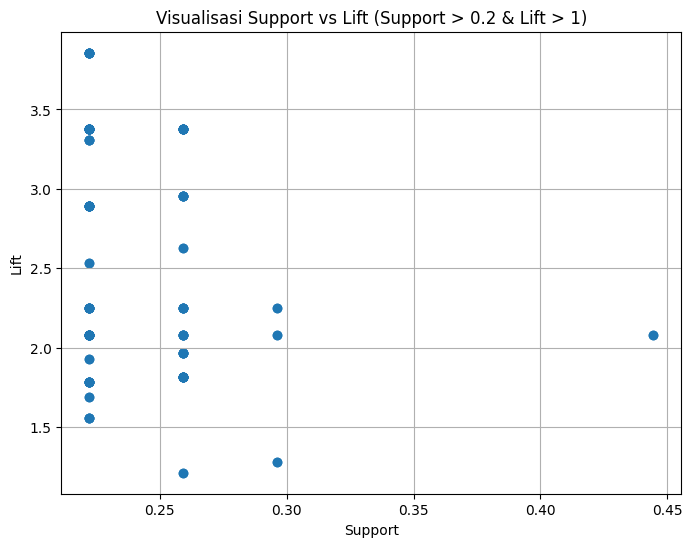

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df_rules_filtered["Support"],
    df_rules_filtered["Lift"]
)

plt.xlabel("Support")
plt.ylabel("Lift")
plt.title("Visualisasi Support vs Lift (Support > 0.2 & Lift > 1)")

plt.grid(True)
plt.show()

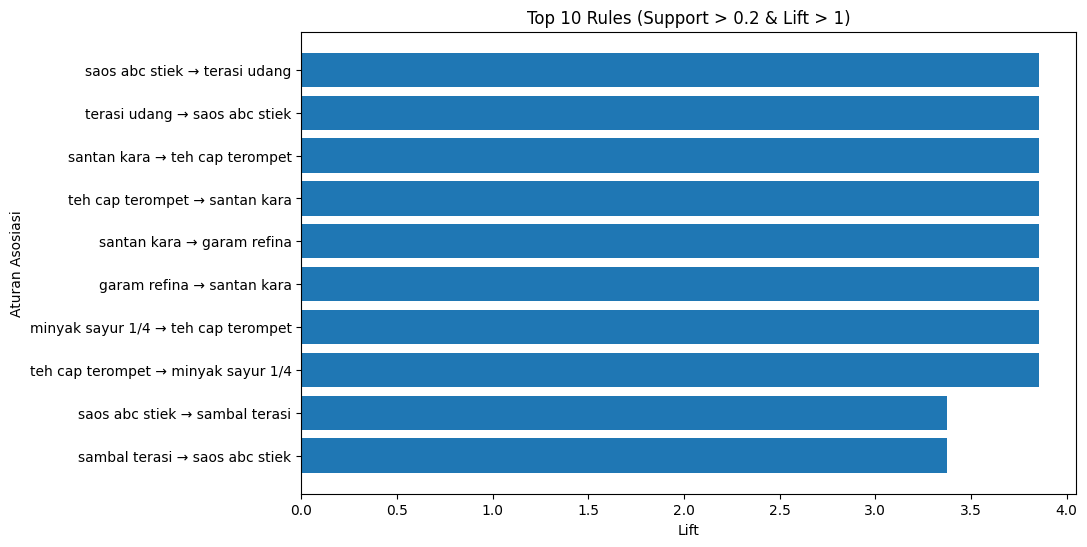

In [55]:
# Ambil Top 10 rules
top_rules = df_rules_filtered.sort_values(by="Lift", ascending=False).head(10)

# Buat label rule
top_rules["Rule"] = top_rules["Antecedent"] + " → " + top_rules["Consequent"]

plt.figure(figsize=(10,6))

plt.barh(top_rules["Rule"], top_rules["Lift"])

plt.xlabel("Lift")
plt.ylabel("Aturan Asosiasi")
plt.title("Top 10 Rules (Support > 0.2 & Lift > 1)")

plt.gca().invert_yaxis()
plt.show()

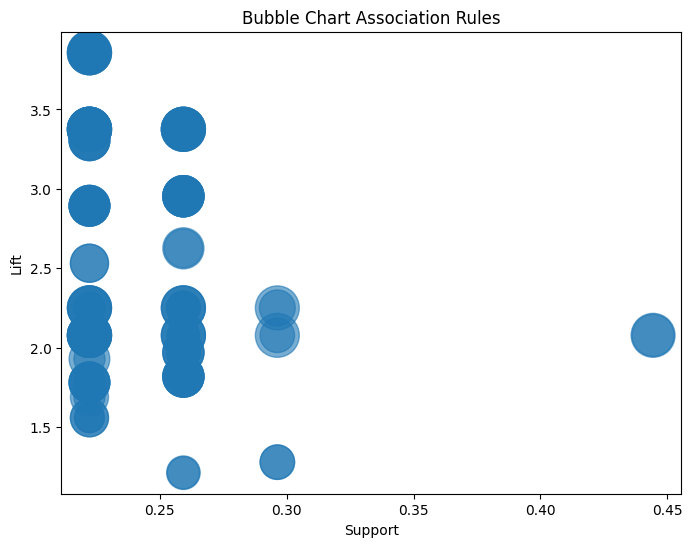

In [56]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_rules_filtered["Support"],
    df_rules_filtered["Lift"],
    s=df_rules_filtered["Confidence"] * 1000,  # ukuran berdasarkan confidence
    alpha=0.6
)

plt.xlabel("Support")
plt.ylabel("Lift")
plt.title("Bubble Chart Association Rules")

plt.show()

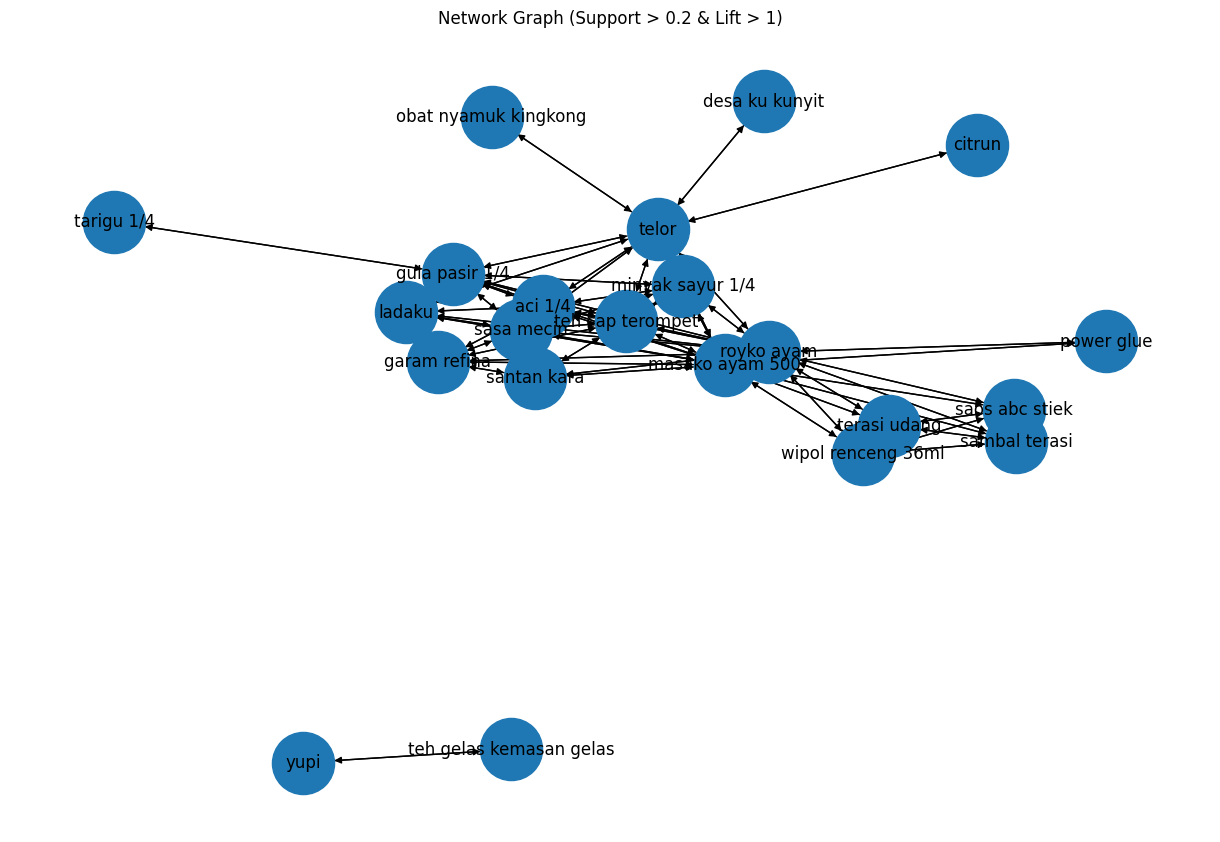

In [57]:
import networkx as nx

G = nx.DiGraph()

for _, row in df_rules_filtered.iterrows():
    G.add_edge(row["Antecedent"], row["Consequent"], weight=row["Lift"])

plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, k=0.5)

nx.draw(G, pos, with_labels=True, node_size=2000)

plt.title("Network Graph (Support > 0.2 & Lift > 1)")
plt.axis('off')
plt.show()